# Task 3.1

This notebook contains the analysis and plots for assignment 3.1.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from brew_utils import *

In [21]:
# 3.1.1
barley_mass = 25.44
v_beer = beer_from_barley(barley_mass)
print("task 3.1.1:", v_beer)

task 3.1.1: 100.00551724137924


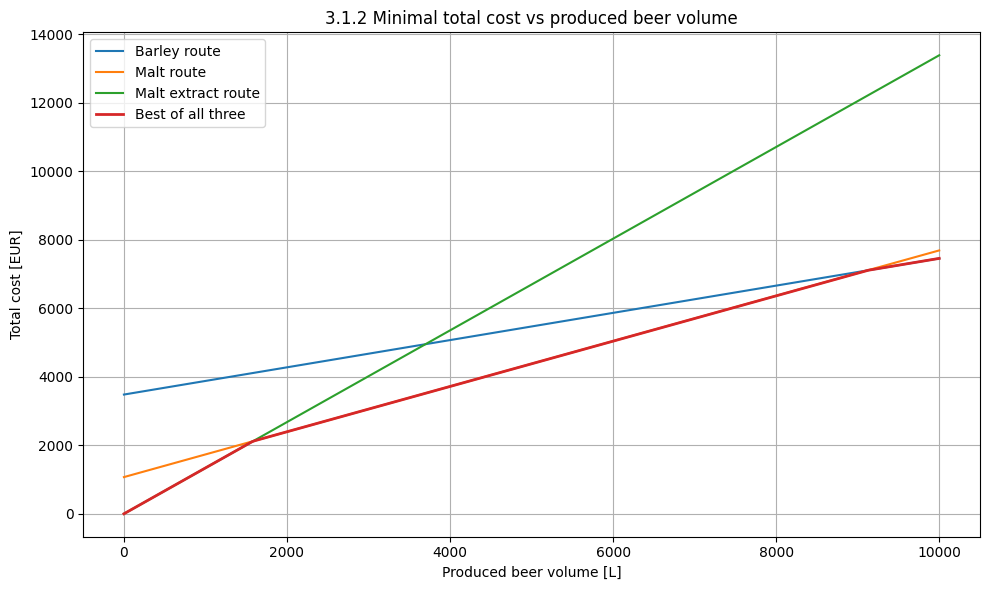

In [22]:
# 3.1.2
CHEAPEST_BARLEY_COST = cheapest_cost(barley)
CHEAPEST_MALT_COST = cheapest_cost(malts)
CHEAPEST_MALTEXTRACT_COST = cheapest_cost(maltextracts)
CHEAPEST_HOP_COST = cheapest_cost(hops)
CHEAPEST_YEAST_COST = cheapest_cost(yeasts)

MALTING_FIXED_COST = float(maltprocess.loc[0, "fixedcost"])
MALTING_VARIABLE_COST = float(maltprocess.loc[0, "variablecost"])
MASHING_FIXED_COST = float(mashingprocess.loc[0, "fixedcost"])
MASHING_VARIABLE_COST = float(mashingprocess.loc[0, "variablecost"])

def barley_route_cost(v_beer):
    m_eq = malt_extract_eq_needed_for_beer(v_beer)
    barley_kg = m_eq / BARLEY_TO_MALTEXTRACT_EQ
    malt_kg = malt_from_barley(barley_kg)

    raw_cost = barley_kg * CHEAPEST_BARLEY_COST
    malting_cost = MALTING_FIXED_COST + MALTING_VARIABLE_COST * barley_kg
    mashing_cost = MASHING_FIXED_COST + MASHING_VARIABLE_COST * malt_kg
    hops_cost = hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
    yeast_cost = yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST

    return raw_cost + malting_cost + mashing_cost + hops_cost + yeast_cost

def malt_route_cost(v_beer):
    m_eq = malt_extract_eq_needed_for_beer(v_beer)
    malt_kg = m_eq / MALT_TO_MALTEXTRACT_EQ

    raw_cost = malt_kg * CHEAPEST_MALT_COST
    mashing_cost = MASHING_FIXED_COST + MASHING_VARIABLE_COST * malt_kg
    hops_cost = hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
    yeast_cost = yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST

    return raw_cost + mashing_cost + hops_cost + yeast_cost

def maltextract_route_cost(v_beer):
    m_eq = equivalent_maltextract_needed_for_beer(v_beer)

    raw_cost = m_eq * CHEAPEST_MALTEXTRACT_COST
    hops_cost = hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
    yeast_cost = yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST

    return raw_cost + hops_cost + yeast_cost

def combined_best_cost(v_beer):
    return min(
        barley_route_cost(v_beer),
        malt_route_cost(v_beer),
        maltextract_route_cost(v_beer),
    )

volumes = np.linspace(1, 10000, 300)
barley_costs = np.array([barley_route_cost(v) for v in volumes])
malt_costs = np.array([malt_route_cost(v) for v in volumes])
maltextract_costs = np.array([maltextract_route_cost(v) for v in volumes])
combined_costs = np.array([combined_best_cost(v) for v in volumes])

plt.figure(figsize=(10, 6))
plt.plot(volumes, barley_costs, label="Barley route")
plt.plot(volumes, malt_costs, label="Malt route")
plt.plot(volumes, maltextract_costs, label="Malt extract route")
plt.plot(volumes, combined_costs, label="Best of all three", linewidth=2)
plt.xlabel("Produced beer volume [L]")
plt.ylabel("Total cost [EUR]")
plt.title("3.1.2 Minimal total cost vs produced beer volume")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<!-- REPORT_TABLE_OUTPUTS_SYNC -->
## Report table outputs

The following tables correspond to the tables used in the LaTeX report for Task 3.1.

In [23]:
# REPORT_TABLE_OUTPUTS_SYNC
import pandas as pd

print("Table 4.1: Task 1 Barley-to-Beer Calculation")
barley_mass = 25.44
extract_equivalent = BARLEY_TO_MALTEXTRACT_EQ * barley_mass
wort_volume = extract_equivalent / (2.9 * (SG - 1.0))
beer_volume = 0.95 * wort_volume

task31_barley_to_beer_table = pd.DataFrame([
    {"Quantity": "Barley mass", "Expression": "$M_B$", "Value": f"{barley_mass:.2f} kg"},
    {"Quantity": "Extract equivalent", "Expression": "$0.6M_B$", "Value": f"{extract_equivalent:.3f} kg"},
    {"Quantity": "Wort volume", "Expression": "$0.6M_B/[2.9(SG-1)]$", "Value": f"{wort_volume:.3f} L"},
    {"Quantity": "Beer volume", "Expression": "$0.95V_{wort}$", "Value": f"{beer_volume:.3f} L"},
])
display(task31_barley_to_beer_table)

print("Table 4.2: Task 1 Cost Breakdown for Separate Source Routes")
def report_route_breakdown(route, v_beer):
    m_eq = malt_extract_eq_needed_for_beer(v_beer)
    h_kg = hops_needed_for_beer(v_beer)
    y_kg = yeast_needed_for_beer(v_beer)
    hop_cost = h_kg * CHEAPEST_HOP_COST
    yeast_cost = y_kg * CHEAPEST_YEAST_COST

    if route == "Barley":
        barley_kg = m_eq / BARLEY_TO_MALTEXTRACT_EQ
        malt_kg = malt_from_barley(barley_kg)
        parts = {
            "Source": barley_kg * CHEAPEST_BARLEY_COST,
            "Hops": hop_cost,
            "Yeast": yeast_cost,
            "Var. malt": MALTING_VARIABLE_COST * barley_kg,
            "Var. mash": MASHING_VARIABLE_COST * malt_kg,
            "Fixed malt": MALTING_FIXED_COST,
            "Fixed mash": MASHING_FIXED_COST,
        }
    elif route == "Malt":
        malt_kg = m_eq / MALT_TO_MALTEXTRACT_EQ
        parts = {
            "Source": malt_kg * CHEAPEST_MALT_COST,
            "Hops": hop_cost,
            "Yeast": yeast_cost,
            "Var. malt": 0.0,
            "Var. mash": MASHING_VARIABLE_COST * malt_kg,
            "Fixed malt": 0.0,
            "Fixed mash": MASHING_FIXED_COST,
        }
    elif route == "Extract":
        parts = {
            "Source": m_eq * CHEAPEST_MALTEXTRACT_COST,
            "Hops": hop_cost,
            "Yeast": yeast_cost,
            "Var. malt": 0.0,
            "Var. mash": 0.0,
            "Fixed malt": 0.0,
            "Fixed mash": 0.0,
        }
    else:
        raise ValueError(route)

    parts["Total"] = sum(parts.values())
    return parts

rows = []
for volume in [50, 5000, 25000]:
    for route in ["Barley", "Malt", "Extract"]:
        row = {"Volume": volume, "Route": route}
        row.update(report_route_breakdown(route, volume))
        rows.append(row)

task31_cost_breakdown_table = pd.DataFrame(rows).round(3)
display(task31_cost_breakdown_table)


Table 4.1: Task 1 Barley-to-Beer Calculation


,Quantity,Expression,Value
0,Barley mass,$M_B$,25.44 kg
1,Extract equivalent,$0.6M_B$,15.264 kg
2,Wort volume,$0.6M_B/[2.9(SG-1)]$,105.269 L
3,Beer volume,$0.95V_{wort}$,100.006 L


Table 4.2: Task 1 Cost Breakdown for Separate Source Routes


,Volume,Route,Source,Hops,Yeast,Var. malt,Var. mash,Fixed malt,Fixed mash,Total
0,50,Barley,0.903,2.319,2.726,4.961,8.967,2410.0,1072.0,3501.876
1,50,Malt,19.079,2.319,2.726,0.000,8.967,0.0,1072.0,1105.092
2,50,Extract,61.892,2.319,2.726,0.000,0.000,0.0,0.0,66.938
3,5000,Barley,90.307,231.947,272.625,496.053,896.711,2410.0,1072.0,5469.643
4,5000,Malt,1907.895,231.947,272.625,0.000,896.711,0.0,1072.0,4381.178
5,5000,Extract,6189.211,231.947,272.625,0.000,0.000,0.0,0.0,6693.783
6,25000,Barley,451.535,1159.737,1363.125,2480.263,4483.553,2410.0,1072.0,13420.213
7,25000,Malt,9539.474,1159.737,1363.125,0.000,4483.553,0.0,1072.0,17617.888
8,25000,Extract,30946.053,1159.737,1363.125,0.000,0.000,0.0,0.0,33468.914
